# Lecture 10, Advection and diffusion in a river

Lecture 9 solved the one-dimensional advection&ndash;diffusion equation for the
temperature of the ocean. The same equation, discretised with the same three-line
update, answers two everyday questions in hydrology:

- **Flood routing** &mdash; a flood wave leaves an upstream reach as a sharp hydrograph.
  What does it look like at a town, a gauge, or a reservoir tens of kilometres
  downstream? It arrives *later* (advection) and *lower and broader* (diffusion).
- **Solute transport** &mdash; a tank truck spills into a stream. When does the plume
  reach the water-supply intake downstream, how concentrated is it when it gets there,
  and how long does it last?

Lectures 7 and 8 produced a streamflow series at a catchment *outlet*. This lecture
carries that water down the channel network. It is also the step from a **lumped**
(zero-dimensional) description of a catchment to a model with one spatial dimension,
and it is the theory behind the Muskingum&ndash;Cunge routing used in HEC-HMS.


In [1]:
# --- Google Colab setup ---
import sys
if "google.colab" in sys.modules:
    %pip install -q numpy pandas matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1) From the Saint-Venant equations to advection&ndash;diffusion

Unsteady flow in an open channel is described by the **Saint-Venant equations**:
conservation of mass, and a momentum balance with terms for local acceleration,
convective acceleration, the water-surface slope, the bed slope $S_0$ and the friction
slope $S_f$. For a flood wave in a river of mild slope, the two acceleration terms and
the water-surface-slope term are small compared with $S_0$ and $S_f$. Dropping them
leaves the **diffusive-wave approximation**, and combining it with mass conservation
gives a single equation for the discharge $Q(x, t)$:

$$\frac{\partial Q}{\partial t} + c\,\frac{\partial Q}{\partial x}
      = D\,\frac{\partial^{2} Q}{\partial x^{2}},$$

where

| symbol | meaning | typical value |
|---|---|---|
| $Q(x,t)$ | discharge at distance $x$ downstream, time $t$ | m³ s⁻¹ |
| $c$ | **kinematic wave celerity**, the speed of the flood wave | 1&ndash;3 m s⁻¹ |
| $D$ | **hydraulic diffusivity**, $D = \dfrac{Q}{2\,B\,S_0}$ | 10²&ndash;10⁴ m² s⁻¹ |
| $B$ | channel top width | m |
| $S_0$ | channel bed slope | &ndash; |

This is exactly the equation of Lecture 9 with temperature $T$ replaced by discharge
$Q$, advective velocity $U$ replaced by the celerity $c$, and diffusivity $\kappa$
replaced by $D$.

**The wave is faster than the water.** For a wide channel with Manning friction the
celerity is $c = \tfrac{5}{3}\,V$, where $V$ is the mean flow *velocity*. A flood wave
travels downstream about **1.67 times faster** than the water particles themselves:
raising the discharge everywhere raises the depth, and that extra depth propagates as a
wave without any single parcel of water having to make the trip. We will see the
consequence in Section 5, where a dissolved pollutant &mdash; which moves *with* the
water at speed $V$ &mdash; lags well behind the flood wave.

- If $D = 0$ the equation reduces to the **kinematic wave**: the hydrograph is carried
  downstream unchanged, only delayed. Peaks never attenuate.
- A non-zero $D$ **spreads** the wave: the peak drops, the rising and falling limbs
  stretch out, and the total volume is conserved.


In [2]:
# Channel geometry -> celerity c and diffusivity D (wide channel, Manning friction)
S0   = 3e-4      # bed slope [-]
B    = 50.0      # channel width [m]
n_m  = 0.040     # Manning roughness [s m^-1/3]
Qref = 150.0     # reference discharge for linearisation [m3/s]

h = (Qref * n_m / (B * S0 ** 0.5)) ** 0.6      # normal depth [m]
V = Qref / (B * h)                             # mean velocity [m/s]
c = (5.0 / 3.0) * V                            # kinematic wave celerity [m/s]
D = Qref / (2.0 * B * S0)                      # hydraulic diffusivity [m2/s]

print(f"normal depth   h = {h:5.2f} m")
print(f"mean velocity  V = {V:5.2f} m/s")
print(f"wave celerity  c = {c:5.2f} m/s   ( = 5/3 V )")
print(f"diffusivity    D = {D:5.0f} m2/s")
print(f"\ntime for the wave to cross a 60 km reach: {60_000 / c / 3600:.1f} h")
print(f"time for a water parcel to cross it:      {60_000 / V / 3600:.1f} h")


normal depth   h =  3.19 m
mean velocity  V =  0.94 m/s
wave celerity  c =  1.57 m/s   ( = 5/3 V )
diffusivity    D =  5000 m2/s

time for the wave to cross a 60 km reach: 10.6 h
time for a water parcel to cross it:      17.7 h


## 2) A numerical router

We discretise the reach into cells of length $\Delta x$ and step forward in time by
$\Delta t$, writing $Q_i^{\,k}$ for the discharge in cell $i$ at time step $k$. The two
terms are treated exactly as in Lecture 9, with one change: because the flow is
one-directional (downstream), we use a **first-order upwind** difference for advection
instead of the centred difference. Upwind differencing looks only at the cell the water
is *coming from*, which is both physically natural here and numerically stable:

$$\frac{\partial Q}{\partial x}\bigg|_i \approx \frac{Q_i^{\,k} - Q_{i-1}^{\,k}}{\Delta x},
\qquad
\frac{\partial^{2} Q}{\partial x^{2}}\bigg|_i \approx
   \frac{Q_{i+1}^{\,k} - 2Q_i^{\,k} + Q_{i-1}^{\,k}}{\Delta x^{2}}.$$

Substituting and solving for the new time level gives the update

$$Q_i^{\,k+1} = Q_i^{\,k}
   - C_r\left(Q_i^{\,k} - Q_{i-1}^{\,k}\right)
   + N_e\left(Q_{i+1}^{\,k} - 2Q_i^{\,k} + Q_{i-1}^{\,k}\right),$$

with the two dimensionless step numbers

$$C_r = \frac{c\,\Delta t}{\Delta x}\ \ (\text{Courant number}),
\qquad
N_e = \frac{D\,\Delta t}{\Delta x^{2}}\ \ (\text{diffusion number}).$$

The explicit scheme is stable only if $C_r \le 1$ (a signal must not skip a cell in one
step), $N_e \le \tfrac12$, and &mdash; because advection and diffusion are stepped
together &mdash; $C_r + 2 N_e \le 1$. So that we can hand the router a hydrograph at any
convenient reporting interval &mdash; minutes, or the daily values of Lecture 7 &mdash;
it splits each reported step into as many equal **sub-steps** as that condition
requires, ramping the upstream boundary linearly across them. Boundary conditions: the
**inflow hydrograph is prescribed** at the upstream end ($x = 0$), and the downstream
end is left open with a **zero-gradient** condition.

```{note}
First-order upwind advection introduces a small amount of *numerical* diffusion,
$D_{\text{num}} = \tfrac{1}{2} c\,\Delta x\,(1 - C_r)$. The Muskingum&ndash;Cunge method
turns this into a feature: it chooses $\Delta x$ so that the numerical diffusion equals
the physical $D$, and then routes with a simple mass-balance (Muskingum) equation. Here
we keep the physical $D$ explicit and just pick $\Delta x$ small enough that the
numerical part is negligible.
```


In [3]:
def route(inflow, dt, *, celerity, diffusivity, dx, reach_length,
          q_init=None, return_field=False):
    """Route an inflow hydrograph down a uniform channel.

    Solves  dQ/dt + c dQ/dx = D d2Q/dx2  with first-order upwind advection and
    a centred diffusion term, explicit in time. Each reported step of length
    `dt` is split into stable sub-steps internally.

    inflow        discharge at the upstream end [m3/s], one value per reported step
    dt            reporting interval [s]
    celerity      c, kinematic wave celerity [m/s]
    diffusivity   D, hydraulic diffusivity [m2/s]
    dx            cell length [m]
    reach_length  length of the routed reach [m]

    Returns the outflow hydrograph at x = reach_length (same length as inflow),
    or, with return_field=True, also the full (n_steps, n_cells) array Q(x, t).
    """
    c, Dd = float(celerity), float(diffusivity)
    n_x = int(round(reach_length / dx)) + 1

    # combined stability limit for upwind advection + centred diffusion:
    #   Cr + 2 Ne <= 1   with   Cr = c h / dx,  Ne = D h / dx^2
    dt_stable = 0.9 / (c / dx + 2.0 * Dd / dx ** 2)
    n_sub = max(1, int(np.ceil(dt / dt_stable)))
    h = dt / n_sub
    Cr = c * h / dx
    Ne = Dd * h / dx ** 2

    inflow = np.asarray(inflow, float)
    Q = np.full(n_x, inflow[0] if q_init is None else float(q_init))
    out = np.empty(len(inflow))
    field = np.empty((len(inflow), n_x)) if return_field else None

    for k in range(len(inflow)):
        q_prev = inflow[k - 1] if k > 0 else inflow[0]
        for m in range(n_sub):                            # stable sub-steps
            Q[0] = q_prev + (inflow[k] - q_prev) * (m + 1) / n_sub
            adv = -Cr * (Q[1:-1] - Q[:-2])                # upwind
            dif = Ne * (Q[2:] - 2.0 * Q[1:-1] + Q[:-2])   # centred 2nd difference
            Q[1:-1] = Q[1:-1] + adv + dif
            Q[-1] = Q[-2]                                 # zero-gradient outflow
        out[k] = Q[-1]
        if return_field:
            field[k] = Q
    return (out, field) if return_field else out


## 3) Routing a synthetic flood wave

Start with a clean, single-peaked inflow hydrograph so that translation and attenuation
are easy to see. The pulse below rises from a baseflow of 20 m³ s⁻¹ to a peak of
180 m³ s⁻¹ four hours in, then recedes &mdash; a flashy response typical of a small
upland catchment.


inflow  peak  180.0 m3/s at t =  4.00 h
outflow peak   96.2 m3/s at t = 13.33 h
peak attenuation : 47 %
peak lag         : 9.33 h (pure translation would give 10.65 h)
volume in  : 9.30 Mm3
volume out : 9.30 Mm3   (should match)


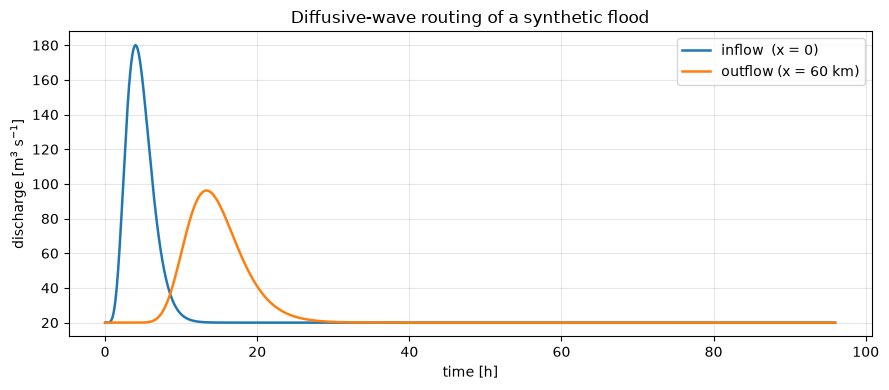

In [4]:
def flood_pulse(t_h, t_peak=4.0, shape=6.0, base=20.0, peak=180.0):
    """A smooth single-peak inflow hydrograph, discharge [m3/s] vs time [h]."""
    tau = np.maximum(t_h, 1e-9) / t_peak
    g = tau ** shape * np.exp(shape * (1.0 - tau))          # = 1 at tau = 1
    return base + (peak - base) * g

dt = 60.0                                    # 1-minute reporting step
t_h = np.arange(0, 96, dt / 3600)            # 4 days
inflow = flood_pulse(t_h)

dx, reach = 500.0, 60_000.0
outflow = route(inflow, dt, celerity=c, diffusivity=D, dx=dx, reach_length=reach)

i_in, i_out = inflow.argmax(), outflow.argmax()
print(f"inflow  peak {inflow[i_in]:6.1f} m3/s at t = {t_h[i_in]:5.2f} h")
print(f"outflow peak {outflow[i_out]:6.1f} m3/s at t = {t_h[i_out]:5.2f} h")
print(f"peak attenuation : {100 * (1 - outflow[i_out] / inflow[i_in]):.0f} %")
print(f"peak lag         : {t_h[i_out] - t_h[i_in]:.2f} h "
      f"(pure translation would give {reach / c / 3600:.2f} h)")
trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
print(f"volume in  : {trapz(inflow, dx=dt) / 1e6:.2f} Mm3")
print(f"volume out : {trapz(outflow, dx=dt) / 1e6:.2f} Mm3   (should match)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_h, inflow, label="inflow  (x = 0)", lw=1.8)
ax.plot(t_h, outflow, label=f"outflow (x = {reach/1000:.0f} km)", lw=1.8)
ax.set_xlabel("time [h]"); ax.set_ylabel("discharge [m$^3$ s$^{-1}$]")
ax.set_title("Diffusive-wave routing of a synthetic flood")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()


The outflow peak arrives about $L/c$ later and is markedly lower; the area under the
two curves (the flood *volume*) is the same. Now watch the wave move along the whole
reach at once.


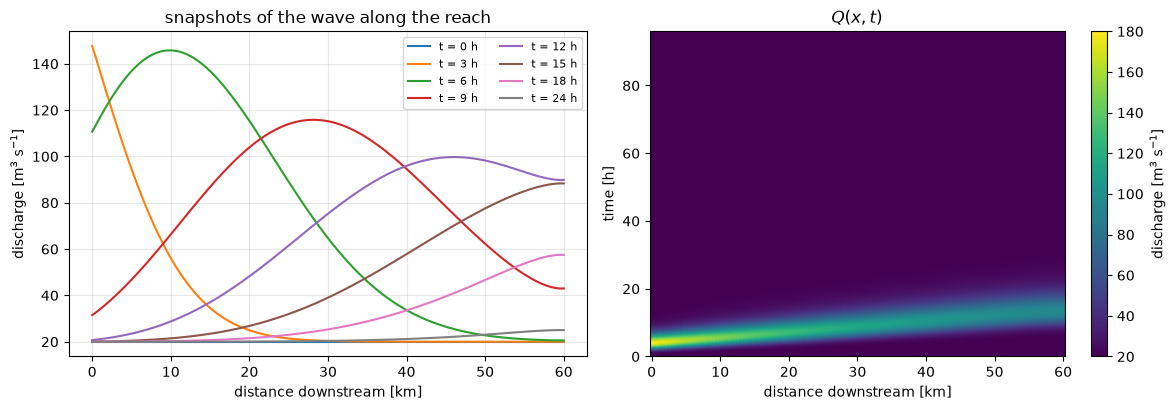

In [5]:
outflow, Qxt = route(inflow, dt, celerity=c, diffusivity=D, dx=dx,
                     reach_length=reach, return_field=True)
x_km = np.arange(Qxt.shape[1]) * dx / 1000

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for hr in [0, 3, 6, 9, 12, 15, 18, 24]:
    k = int(hr * 3600 / dt)
    ax[0].plot(x_km, Qxt[k], label=f"t = {hr} h")
ax[0].set_xlabel("distance downstream [km]"); ax[0].set_ylabel("discharge [m$^3$ s$^{-1}$]")
ax[0].set_title("snapshots of the wave along the reach")
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=0.3)

im = ax[1].pcolormesh(x_km, t_h, Qxt, shading="auto", cmap="viridis")
ax[1].set_xlabel("distance downstream [km]"); ax[1].set_ylabel("time [h]")
ax[1].set_title("$Q(x, t)$")
fig.colorbar(im, ax=ax[1], label="discharge [m$^3$ s$^{-1}$]")
fig.tight_layout()


The bright ridge in the space&ndash;time plot is the flood crest. Its slope is the wave
celerity $c$; the way it fades and widens with distance is the diffusion $D$ at work.

### How much does $D$ matter?

Hold the channel geometry fixed and sweep the diffusivity from zero (pure kinematic
translation) to several times its nominal value.


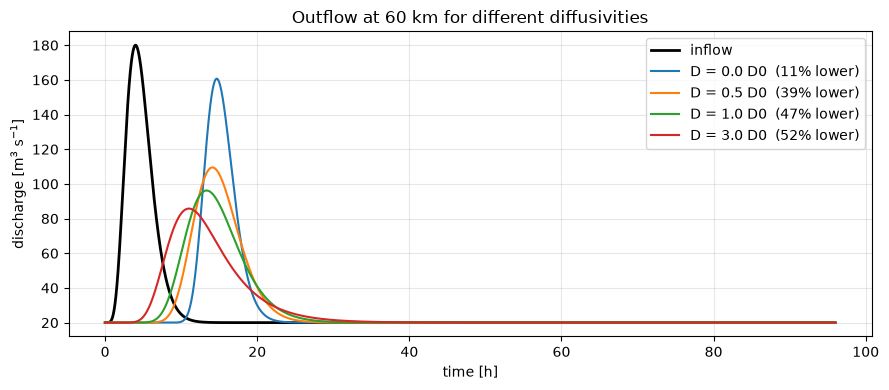

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_h, inflow, "k", lw=2, label="inflow")
for factor in [0.0, 0.5, 1.0, 3.0]:
    q = route(inflow, dt, celerity=c, diffusivity=factor * D, dx=dx, reach_length=reach)
    att = 100 * (1 - q.max() / inflow.max())
    ax.plot(t_h, q, lw=1.5, label=f"D = {factor:.1f} D0  ({att:.0f}% lower)")
ax.set_xlabel("time [h]"); ax.set_ylabel("discharge [m$^3$ s$^{-1}$]")
ax.set_title(f"Outflow at {reach/1000:.0f} km for different diffusivities")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()


The $D = 0$ line is *mostly* a time shift: a pure kinematic wave carries the peak
downstream almost undiminished. It still loses a little height here &mdash; that
residual is the **numerical diffusion** of the upwind scheme from Section 2, not
physics, and it shrinks if the grid is refined. Every real channel adds genuine
$D > 0$: friction and temporary storage in the channel and on its banks spread the wave
and take the edge off the flood. A steeper channel (larger $S_0$) has a *smaller*
$D = Q/(2 B S_0)$ and passes the flood on with less attenuation, which is one reason
steep headwater tributaries are so flashy.


## 4) Routing a real flood: the Chattooga downstream

Take the observed streamflow of the Chattooga River from Lecture 7, pick out the
largest flood in the record, and route it down a hypothetical 40 km reach toward a
downstream community.

The record is a catchment-average depth in mm day⁻¹. Convert it to a discharge with the
catchment area $A = 536$ km²:

$$Q\,[\text{m}^3\text{s}^{-1}] = q\,[\text{mm d}^{-1}]\times\frac{A\,[\text{km}^2]}{86.4}.$$


largest flood on record: 2004-09-17  (524 m3/s, 84 mm/day)

inflow  peak    524 m3/s
outflow peak    404 m3/s  (23% lower)
centroid lag 4.3 h  (pure translation: 7.1 h)
-> that delay is the warning time the reach buys the town downstream


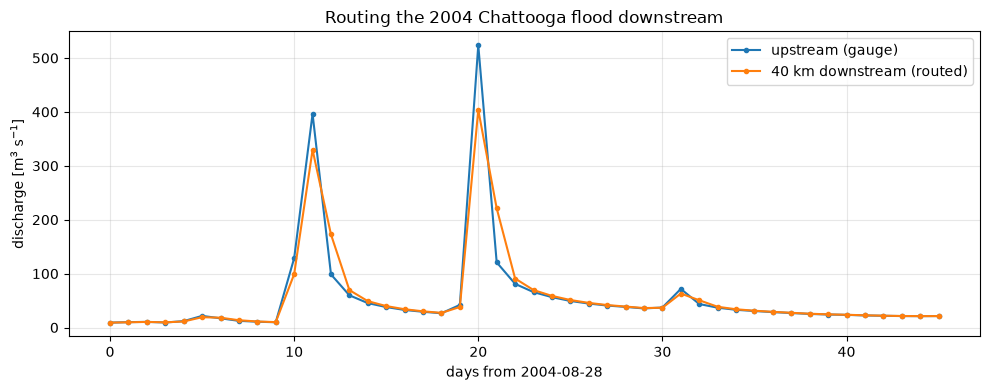

In [7]:
df = pd.read_csv("data/chattooga_daily.csv", comment="#",
                 parse_dates=["date"], index_col="date")
A_km2 = 536.0
df["Q_cms"] = df["q_mm"] * A_km2 / 86.4

peak_day = df["Q_cms"].idxmax()
print(f"largest flood on record: {peak_day.date()}  "
      f"({df.loc[peak_day, 'Q_cms']:.0f} m3/s, {df.loc[peak_day, 'q_mm']:.0f} mm/day)")

event = df.loc[peak_day - pd.Timedelta(days=20): peak_day + pd.Timedelta(days=25), "Q_cms"]

# hand the router the daily series directly; it sub-steps internally
inflow_r = event.values
t_days = np.arange(len(event))

dx_r, reach_r = 2500.0, 40_000.0
outflow_r = route(inflow_r, 86400.0, celerity=c, diffusivity=D,
                  dx=dx_r, reach_length=reach_r)

pin, pout = inflow_r.argmax(), outflow_r.argmax()
lag_h = np.trapezoid(t_days * outflow_r, t_days) / np.trapezoid(outflow_r, t_days) \
      - np.trapezoid(t_days * inflow_r, t_days) / np.trapezoid(inflow_r, t_days)
print(f"\ninflow  peak {inflow_r[pin]:6.0f} m3/s")
print(f"outflow peak {outflow_r[pout]:6.0f} m3/s  "
      f"({100 * (1 - outflow_r[pout] / inflow_r[pin]):.0f}% lower)")
print(f"centroid lag {lag_h * 24:.1f} h  (pure translation: {reach_r / c / 3600:.1f} h)")
print("-> that delay is the warning time the reach buys the town downstream")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_days, inflow_r, "o-", ms=3, label="upstream (gauge)", lw=1.5)
ax.plot(t_days, outflow_r, "o-", ms=3, label="40 km downstream (routed)", lw=1.5)
ax.set_xlabel(f"days from {event.index[0].date()}")
ax.set_ylabel("discharge [m$^3$ s$^{-1}$]")
ax.set_title(f"Routing the {peak_day.year} Chattooga flood downstream")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()


The downstream hydrograph peaks lower and later. For a flood warning that delay is the
useful product: it is the lead time a downstream town gains simply from the flood
having to travel the channel. A distributed hydrological model (SWAT, VIC, HEC-HMS)
does this routing on *every* channel segment of a river network; here we have done it
for one reach, with the same equation.


## 5) The same equation for a pollutant: the advection&ndash;dispersion equation

Replace discharge with the concentration $C(x, t)$ of a dissolved substance, the wave
celerity with the mean flow velocity $V$, and the hydraulic diffusivity with the
**longitudinal dispersion coefficient** $D_L$ (shear across the channel stretches a
patch of tracer far faster than molecular diffusion):

$$\frac{\partial C}{\partial t} + V\,\frac{\partial C}{\partial x}
      = D_L\,\frac{\partial^{2} C}{\partial x^{2}}.$$

For an **instantaneous release** of mass $M$ into a stream of cross-sectional area $A$,
this equation has the exact solution

$$C(x, t) = \frac{M}{A\,\sqrt{4\pi D_L t}}\,
            \exp\!\left(-\frac{(x - V t)^{2}}{4 D_L t}\right),$$

a Gaussian plume whose centre of mass travels at $V$, whose width grows as
$\sigma = \sqrt{2 D_L t}$, and whose peak concentration falls as $t^{-1/2}$. We can use
this to **check a numerical scheme**: start it from the analytic plume at an early time
and see whether it reproduces the analytic plume later.

For the flood wave we used *upwind* advection, which is stable but adds a little
numerical diffusion &mdash; harmless there because $D$ is large anyway. A dilute plume
is unforgiving: that numerical diffusion would masquerade as extra dispersion and
flatten the peak. So here we use the **centred** advection difference of Lecture 9
instead. Centred advection is only stable when the physical diffusion is strong enough
relative to the grid, which is the condition that the **cell Péclet number** stay below
about 2:

$$\mathrm{Pe}_{\Delta x} = \frac{V\,\Delta x}{D_L} \lesssim 2
\qquad\Longrightarrow\qquad \Delta x \lesssim \frac{2 D_L}{V}.$$

That is why solute-transport grids have to be fine.


cell Peclet number Pe = 0.94   (needs to stay below ~2)


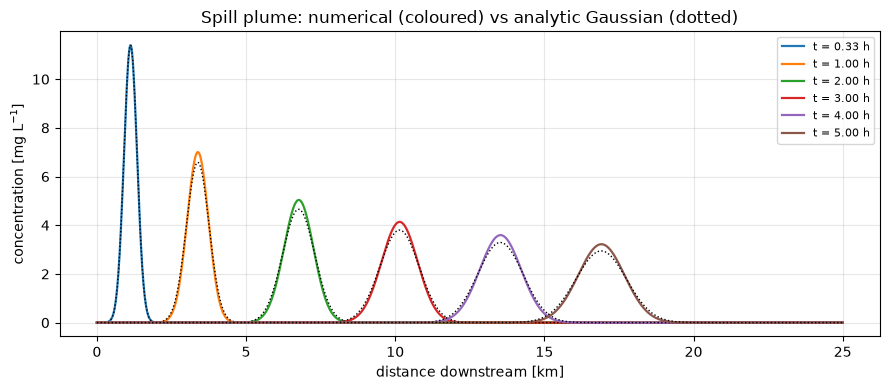

In [8]:
def plume_analytic(x, t, M, A, V, DL):
    return M / (A * np.sqrt(4 * np.pi * DL * t)) * np.exp(-(x - V * t) ** 2 / (4 * DL * t))

def transport(C0, dt, *, velocity, dispersion, dx, n_steps):
    """Advection-dispersion of a concentration profile: centred advection
    (Lecture 9) + centred diffusion, explicit. Returns a list of profiles."""
    V, DL = float(velocity), float(dispersion)
    Cr, Ne = V * dt / dx, DL * dt / dx ** 2
    C = np.asarray(C0, float).copy()
    hist = [C.copy()]
    for _ in range(n_steps):
        adv = -Cr * (C[2:] - C[:-2]) / 2.0
        dif = Ne * (C[2:] - 2.0 * C[1:-1] + C[:-2])
        C[1:-1] = C[1:-1] + adv + dif
        C[0] = 0.0; C[-1] = C[-2]
        hist.append(C.copy())
    return hist

M   = 1000.0                     # kg spilled
A_c = B * h                      # channel cross-section [m2]
DL  = 20.0                       # longitudinal dispersion [m2/s]

dx_s = 20.0                      # << 2 DL / V, so the cell Peclet number is ~0.9
dt_s = 8.0
print(f"cell Peclet number Pe = {V * dx_s / DL:.2f}   (needs to stay below ~2)")

xg = np.arange(0, 25_000 + dx_s, dx_s)
t0 = 1200.0                                       # start 20 min after the release
C0 = plume_analytic(xg, t0, M, A_c, V, DL)        # initial condition = analytic plume
n_steps = int(5 * 3600 / dt_s)
hist = transport(C0, dt_s, velocity=V, dispersion=DL, dx=dx_s, n_steps=n_steps)

fig, ax = plt.subplots(figsize=(9, 4))
for hr in [0, 1, 2, 3, 4, 5]:
    tt = t0 if hr == 0 else hr * 3600
    k = 0 if hr == 0 else int((tt - t0) / dt_s)
    ax.plot(xg / 1000, hist[k] * 1000, lw=1.6, label=f"t = {tt/3600:.2f} h")
    ax.plot(xg / 1000, plume_analytic(xg, tt, M, A_c, V, DL) * 1000, "k:", lw=1.0)
ax.set_xlabel("distance downstream [km]"); ax.set_ylabel("concentration [mg L$^{-1}$]")
ax.set_title("Spill plume: numerical (coloured) vs analytic Gaussian (dotted)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()


The numerical solution now tracks the analytic Gaussian closely &mdash; the centre of
mass, the spreading rate and the falling peak all match (a faint ripple in the tail is
the dispersive error of the centred scheme, shrinking as the grid is refined). The
solver is trustworthy. Use it &mdash; or, since we have it, the exact solution &mdash;
to answer the operational question: a **water-supply intake sits 15 km downstream**.
What does the spill look like there?


flow velocity V       = 0.94 m/s
plume centre reaches the intake at t = 4.44 h
peak concentration    = 3.13 mg/L  at t = 4.43 h
above 1 mg/L from t = 4.09 h to t = 4.80 h  (0.71 h window)


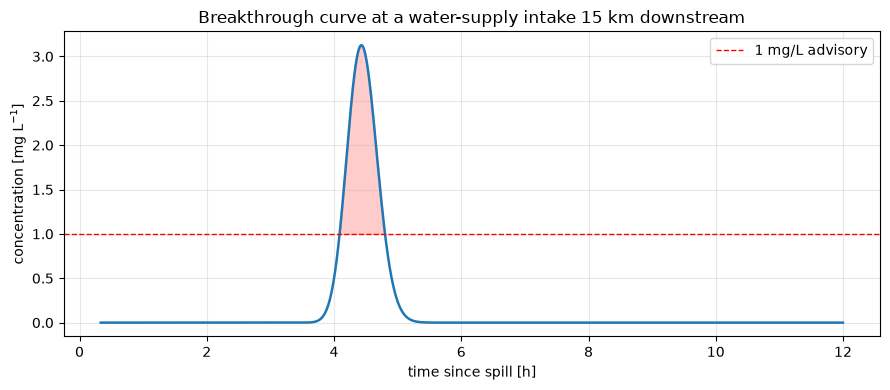

In [9]:
x_intake = 15_000.0
tg = np.arange(t0, 12 * 3600, dt_s)
C_intake = plume_analytic(x_intake, tg, M, A_c, V, DL) * 1000    # mg/L

arrival = tg[C_intake.argmax()]
threshold = 1.0                                                  # mg/L advisory level
above = tg[C_intake > threshold]

print(f"flow velocity V       = {V:.2f} m/s")
print(f"plume centre reaches the intake at t = {x_intake / V / 3600:.2f} h")
print(f"peak concentration    = {C_intake.max():.2f} mg/L  at t = {arrival/3600:.2f} h")
if above.size:
    print(f"above {threshold:.0f} mg/L from t = {above[0]/3600:.2f} h "
          f"to t = {above[-1]/3600:.2f} h  ({(above[-1]-above[0])/3600:.2f} h window)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tg / 3600, C_intake, lw=1.8)
ax.axhline(threshold, color="r", ls="--", lw=1, label=f"{threshold:.0f} mg/L advisory")
ax.fill_between(tg / 3600, C_intake, threshold, where=C_intake > threshold,
                color="r", alpha=0.2)
ax.set_xlabel("time since spill [h]"); ax.set_ylabel("concentration [mg L$^{-1}$]")
ax.set_title("Breakthrough curve at a water-supply intake 15 km downstream")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()


**Two different lead times.** A flood wave in this channel travels at the celerity
$c = \tfrac{5}{3}V \approx$ 1.6 m s⁻¹; a dissolved contaminant drifts with the water at
$V \approx$ 0.9 m s⁻¹. The pollutant takes about **1.7 times longer** to reach the same
point downstream. Flood forecasting and spill response are the same equation with
different transport speeds &mdash; and the spill gives more warning, though it also
lasts longer as it passes.


## 6) How to read these results

**A routed hydrograph** (Sections 3&ndash;4) shows two things at once:

- *Translation* &mdash; how far the peak shifts along the time axis. Divided by the
  reach length this is the wave celerity, and it is the warning time a downstream
  location gains for free.
- *Attenuation* &mdash; how much lower the outflow peak is than the inflow peak. It
  measures how much the channel and its floodplain store and release during the event.
  A reach with large $D$ (mild slope, wide floodplain) is a natural flood buffer; a
  steep reach passes the flood on almost intact. The area under the curve does not
  change &mdash; routing moves and reshapes a flood, it does not make water disappear.

**A breakthrough curve** (Section 5) is read in three parts:

- *Arrival* &mdash; the leading edge, set by advection at speed $V$: the earliest a
  problem can appear at the intake.
- *Peak* &mdash; the worst concentration and when it occurs; it falls as $t^{-1/2}$
  with distance, so a spill dilutes as it travels.
- *Tail* &mdash; how long the concentration stays above an advisory level, i.e. how
  long an intake must stay closed.


## 7) Exercises

```{admonition} Exercise 1 &mdash; a discharge-dependent celerity
:class: tip
The celerity $c = \tfrac{5}{3}V$ actually grows with discharge, so the crest of a
flood moves faster than its base. Recompute $c$ and $D$ from the *local* discharge each
time step (make them arrays over $x$) and re-route the synthetic wave. Show that the
rising limb steepens as the wave moves downstream &mdash; the beginning of a kinematic
shock.
```

```{admonition} Exercise 2 &mdash; two reaches and a tributary
:class: tip
Route the Chattooga flood through a first reach, add a tributary inflow hydrograph at
its end, then route the sum through a second reach. Compare the peak at the bottom with
and without the tributary, and with the case where the tributary peaks a day earlier.
```

```{admonition} Exercise 3 &mdash; continuous injection
:class: tip
Instead of an instantaneous spill, inject a constant concentration $C_0$ at $x = 0$
starting at $t = 0$. The analytic solution is now the Ogata&ndash;Banks equation, which
uses the complementary error function `scipy.special.erfc`. Run your solver, overlay
the analytic curve, and find how long the intake takes to reach $0.5\,C_0$.
```

```{admonition} Exercise 4 &mdash; route your calibrated model
:class: tip
Take the calibrated Chattooga hydrograph from Lecture 8, route it to a real USGS gauge
some distance downstream, and compare the routed series with that gauge's record. How
much of the remaining error is routing, and how much is the catchment model?
```


## Sources

This notebook is written for this course. It applies the one-dimensional
advection&ndash;diffusion solver of Lecture 9 (adapted there from *Climate of the
Ocean* and the MIT *Computational Thinking* material) to two hydrological problems.

**Theory.**
Chow, V. T., Maidment, D. R., & Mays, L. W. (1988). *Applied Hydrology*, Ch. 9
(distributed flow routing; diffusive-wave and Muskingum&ndash;Cunge methods).
Cunge, J. A. (1969). On the subject of a flood propagation computation method
(Muskingum method). *Journal of Hydraulic Research, 7*(2), 205&ndash;230.
Fischer, H. B., List, E. J., Koh, R. C. Y., Imberger, J., & Brooks, N. H. (1979).
*Mixing in Inland and Coastal Waters* (longitudinal dispersion).
Ogata, A., & Banks, R. B. (1961). A solution of the differential equation of
longitudinal dispersion in porous media. *USGS Professional Paper 411-A*.

**Data.** Chattooga River streamflow as in Lecture 7: U.S. Geological Survey NWIS gauge
02177000 (public domain); the reach geometry and spill scenario are illustrative.
